### Crypto-ML-Pairs-Trading (CLEAN) (Perp. Futures) (BinanceEX/HyperLiquid)

<b><u> Statistical-Arbitraging </u></b>

1. Start beta-neutral to isolate and test if strategy generates true alpha, independent of market moves.

2. Evaluate signal quality, if consistent alpha shows up, it's a valid edge and not just hidden beta.

3. Add back beta exposure (e.g., via index ETFs) to scale returns, creating a robust (beta + alpha) portfolio.

<p align="center">
  <span style="font-size:24px; font-weight:bold;"> Trade System Architecture (R&D) </span><br>
  <img src="../theory/ML-pairs-open-arch.png" width="40%">
</p>


#### Research

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import os
from pprint import pprint
import seaborn as sns
from IPython.display import display
import time
from warnings import filterwarnings
import importlib
import pickle
import json

filterwarnings('ignore') 

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [6]:
import utils
import utils.methods
import utils.retrieve
import utils.cluster
import utils.benchmark
import utils.portfolio
import utils.position

importlib.reload(utils.methods)
importlib.reload(utils.retrieve)
importlib.reload(utils.cluster)
importlib.reload(utils.benchmark)
importlib.reload(utils.portfolio)
importlib.reload(utils.position)

<module 'utils.position' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\position.py'>

In [7]:
from utils.methods import *
from utils.retrieve import *
from utils.cluster import *
from utils.benchmark import *
from utils.portfolio import *
from utils.position import *

In [12]:
with open("config.json", "r") as f:
    config = json.load(f)

# Access variables
const_inner_col = config["cryp_tmp_fields"]
cryp_market = config["cryp_benchmark"]
start = config["start"]
end = config["end"]
day_limit = config["day_limit"]
variance_perc = config["variance_perc"]
cluster_distance_threshold = config["cluster_distance_threshold"]
cluster_percentile = config["cluster_percentile"]

print(const_inner_col, start, end)

['close', 'open', 'high', 'low', 'volume'] 2021-01-01 2024-12-31


Data-Load (BinanceEX API)

In [13]:
stable_ticker = 'USDC/USDT'
history_limit = 1000

In [14]:
df_cryp_uni, cryp_uni_list = get_ccxt_crypto_data(timeframe='1d', limit=history_limit, is_plot=False, load_universe=True)

stablecoin_df = df_cryp_uni.loc[stable_ticker]

df_cryp_uni.drop([stable_ticker], axis=0)
cryp_uni_list = [c for c in cryp_uni_list if c not in [stable_ticker]]

USDT-markets-retrieved:  597 ['BTC/USDT', 'ETH/USDT']
Batch fetch_tickers failed: binance GET https://api.binance.com/api/v3/ticker/24hr?symbols=%5B%22BTCUSDT%22%2C%22ETHUSDT%22%2C%22BNBUSDT%22%2C%22BCCUSDT%22%2C%22NEOUSDT%22%2C%22LTCUSDT%22%2C%22QTUMUSDT%22%2C%22ADAUSDT%22%2C%22XRPUSDT%22%2C%22EOSUSDT%22%2C%22TUSDUSDT%22%2C%22IOTAUSDT%22%2C%22XLMUSDT%22%2C%22ONTUSDT%22%2C%22TRXUSDT%22%2C%22ETCUSDT%22%2C%22ICXUSDT%22%2C%22VENUSDT%22%2C%22NULSUSDT%22%2C%22VETUSDT%22%2C%22PAXUSDT%22%2C%22BCHABCUSDT%22%2C%22BCHSVUSDT%22%2C%22USDCUSDT%22%2C%22LINKUSDT%22%2C%22WAVESUSDT%22%2C%22BTTUSDT%22%2C%22USDSUSDT%22%2C%22ONGUSDT%22%2C%22HOTUSDT%22%2C%22ZILUSDT%22%2C%22ZRXUSDT%22%2C%22FETUSDT%22%2C%22BATUSDT%22%2C%22XMRUSDT%22%2C%22ZECUSDT%22%2C%22IOSTUSDT%22%2C%22CELRUSDT%22%2C%22DASHUSDT%22%2C%22NANOUSDT%22%2C%22OMGUSDT%22%2C%22THETAUSDT%22%2C%22ENJUSDT%22%2C%22MITHUSDT%22%2C%22MATICUSDT%22%2C%22ATOMUSDT%22%2C%22TFUELUSDT%22%2C%22ONEUSDT%22%2C%22FTMUSDT%22%2C%22ALGOUSDT%22%2C%22USDSBUSDT%22%2C%22GTOU

open     high      low    close        volume
symbol   datetime                                                    
ETH/USDT 2022-11-05  1644.78  1666.97  1621.42  1626.98  3.513855e+05
         2022-11-06  1626.98  1639.02  1564.39  1568.29  4.148640e+05
         2022-11-07  1568.25  1608.04  1545.03  1568.10  6.424094e+05
         2022-11-08  1568.09  1579.98  1233.00  1334.77  2.339917e+06
         2022-11-09  1334.78  1337.16  1073.53  1102.73  2.494798e+06

In [16]:
print('Selected-coins (except market & stable): ', len(cryp_uni_list), cryp_uni_list[:5])
print()
display(df_cryp_uni.head(2))
print()
display(stablecoin_df.head(2))

Selected-coins (except market & stable):  95 ['ETH/USDT', 'BTC/USDT', 'SOL/USDT', 'XRP/USDT', 'BNB/USDT']



open     high      low    close       volume
symbol   datetime                                                   
ETH/USDT 2022-11-05  1644.78  1666.97  1621.42  1626.98  351385.5362
         2022-11-06  1626.98  1639.02  1564.39  1568.29  414863.9525

,open,high,low,close,volume
datetime,,,,,
2022-05-24,1.0012,1.0013,1.001,1.0011,227450495.0
2022-05-25,1.0011,1.0013,1.001,1.0010,228221738.0


#### ~2.5 Years API Call-Limit
Different tokens got listed at different times in Binance, and some got de-listed at different times 

Rnd-Coin-Chosen:  HIGH/USDT


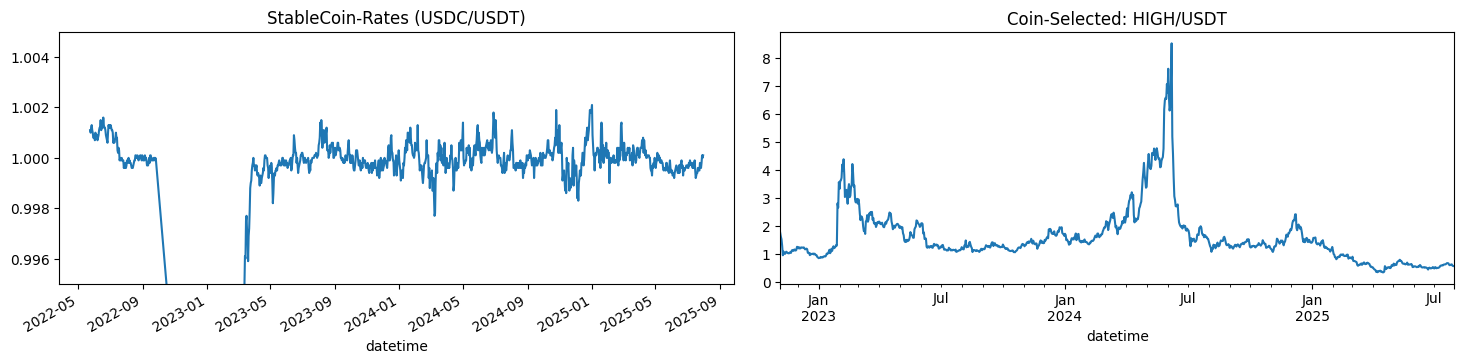

In [21]:
rn_coin = random.randint(0, len(cryp_uni_list))
rn_coin = cryp_uni_list[rn_coin]
print('Rnd-Coin-Chosen: ', rn_coin)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

stablecoin_df.close.plot(ax=axs[0])
axs[0].set_title('StableCoin-Rates (USDC/USDT)')
axs[0].set_ylim(0.995, 1.005)

df_cryp_uni.loc[rn_coin].close.plot(ax=axs[1])
axs[1].set_title(f'Coin-Selected: {rn_coin}')

plt.tight_layout(pad=2)
plt.show()

In [22]:
sub_sample = 20

In [23]:
stocks = np.random.choice(np.array(cryp_uni_list), size=sub_sample).tolist()
print('sampled-selected: ', stocks)

df_uni = df_cryp_uni.copy()
df_uni = df_uni.loc[stocks]

df_cleaned = []
for nm in stocks:
    df_filtered = df_uni.loc[nm].copy()
    df_filtered = df_filtered[~df_filtered.index.duplicated(keep='first')]
    df_filtered['symbol'] = nm  
    df_cleaned.append(df_filtered)

# Combine and set multi-index again
df_uni = pd.concat(df_cleaned).set_index('symbol', append=True).swaplevel()
df_uni = df_uni.sort_index()

display(df_uni.head(3))

sampled-selected:  ['1INCH/USDT', 'BTC/USDT', 'API3/USDT', 'CELR/USDT', 'ETH/USDT', 'SAND/USDT', 'WRX/USDT', 'BTC/USDT', 'CRV/USDT', 'LDO/USDT', 'UNI/USDT', 'DASH/USDT', 'FLOW/USDT', 'ROSE/USDT', 'STORJ/USDT', 'KSM/USDT', 'STX/USDT', 'INJ/USDT', 'SUSHI/USDT', 'ZRX/USDT']


open   high    low  close     volume
symbol     datetime                                         
1INCH/USDT 2022-11-05  0.652  0.664  0.632  0.646  7098888.7
           2022-11-06  0.647  0.675  0.629  0.634  9554653.4
           2022-11-07  0.634  0.662  0.622  0.635  8017818.0

Multi-Visualization (RAW)

LEN_1INCH/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_BTC/USDT: 2000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_API3/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_CELR/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_ETH/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_SAND/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_WRX/USDT: 1000 | start=2022-04-01 00:00:00, end=2024-12-25 00:00:00
LEN_BTC/USDT: 2000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_CRV/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_LDO/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_UNI/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_DASH/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_FLOW/USDT: 1000 | start=2022-11-05 00:00:00, end=2025-07-31 00:00:00
LEN_ROSE/USDT: 1000 | start=2022-11-05 00:00:00, end=2025

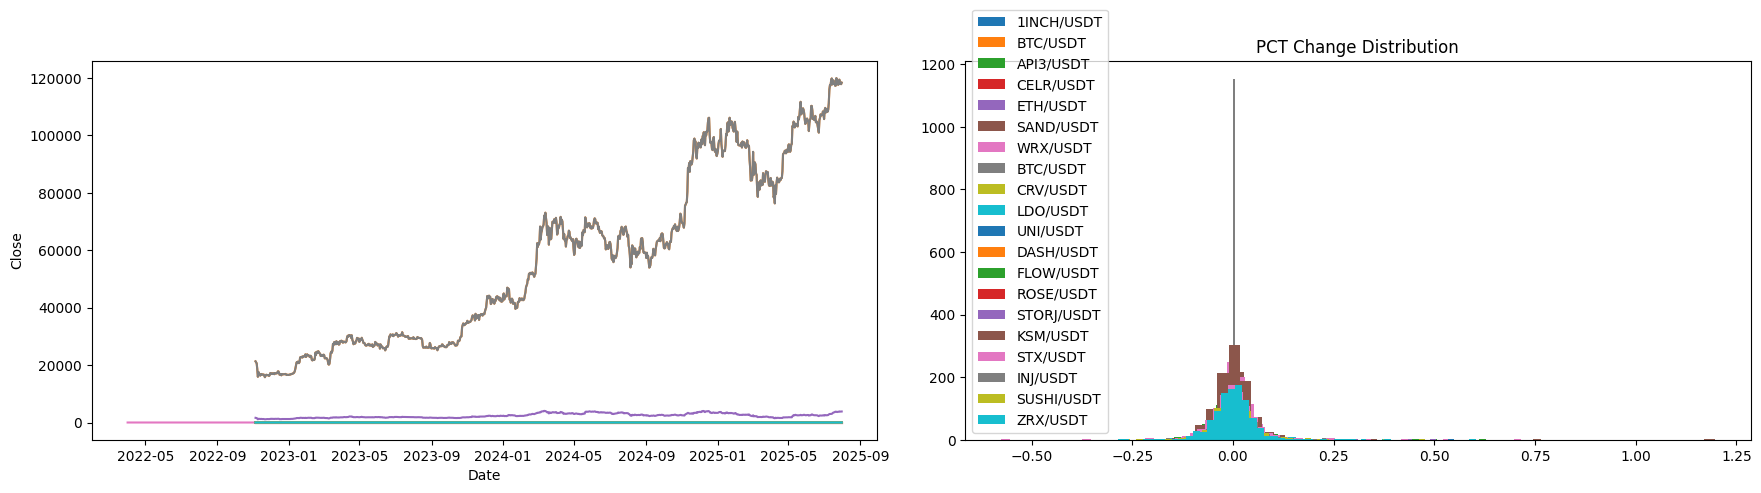

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

### We just do multi-indexing
for nm in stocks:
    print(f'LEN_{nm}: {len(df_uni.loc[nm].index)} | start={df_uni.loc[nm].index[0]}, end={df_uni.loc[nm].index[-1]}')
    axs[0].plot(df_uni.loc[nm].index, df_uni.loc[nm]['close'], label = nm)
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('Close')

plt.legend()

for nm in stocks:

    pct_change_clean = df_uni.loc[nm]['close'].pct_change().dropna()

    if pct_change_clean.empty:
        print(f"Skipping {nm} due to no valid percentage change data.")
        continue
    
    axs[1].hist(pct_change_clean, bins = 50, label = nm)
    axs[1].set_title(f'PCT Change Distribution')

plt.tight_layout(pad = 2)
plt.legend()
plt.show()

Data-Cleaning 

In [25]:
## returns factor-arrays (takes types and fundamental_df)
val_arr, stocks = data_clean(df_uni=df_uni, stocks=stocks, history_limit=history_limit, type='cryp', fund_df=None, is_plot=False)
    
print(len(val_arr), len(val_arr[0]))
val_arr = np.array(val_arr)
print(val_arr.shape)

print('New-Stocks: ', stocks)
print(len(stocks))

val_arr = val_arr.reshape(len(stocks), -1)
print(val_arr.shape)

Data-Cleaning ...
token WRX/USDT de-listed!
time-taken for data-cleaning:  0.0005659659703572592  mins
19 3
(19, 3, 1000)
New-Stocks:  ['1INCH/USDT', 'BTC/USDT', 'API3/USDT', 'CELR/USDT', 'ETH/USDT', 'SAND/USDT', 'BTC/USDT', 'CRV/USDT', 'LDO/USDT', 'UNI/USDT', 'DASH/USDT', 'FLOW/USDT', 'ROSE/USDT', 'STORJ/USDT', 'KSM/USDT', 'STX/USDT', 'INJ/USDT', 'SUSHI/USDT', 'ZRX/USDT']
19
(19, 3000)


PortFolio-Construction

In [31]:
import utils
import utils.retrieve
import utils.benchmark

importlib.reload(utils.retrieve)
importlib.reload(utils.benchmark)

from utils.retrieve import *
from utils.benchmark import *

In [49]:
import utils

importlib.reload(utils.factor_model)
importlib.reload(utils.market_proxy)
importlib.reload(utils.alpha_ex)
importlib.reload(utils.beta_ex)
importlib.reload(utils.portfolio)
importlib.reload(utils.risk_engine)
importlib.reload(utils.backtest)
importlib.reload(utils.forward_test)
importlib.reload(utils.analytics)

<module 'utils.analytics' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\analytics.py'>

In [50]:
from utils.factor_model import *
from utils.alpha_ex import *
from utils.beta_ex import *
from utils.portfolio import *
from utils.risk_engine import *
from utils.backtest import *
from utils.forward_test import *
from utils.analytics import *
from utils.market_proxy import * 

##### For the research env everything will be executed independently akin to their modularized nature

In [37]:
# 'test_data' to independently check indiviual components
timeline = df_uni.loc[stocks[0]].index
test_time_index = random.randint(0, len(timeline) - 1)
test_time = timeline[test_time_index]

print('test_time/test_time_index: ', test_time, '|', test_time_index, '|', type(test_time))
display(df_uni.head(3))

test_time/test_time_index:  2024-08-28 00:00:00 | 662 | <class 'pandas._libs.tslibs.timestamps.Timestamp'>


open   high    low  close     volume
symbol     datetime                                         
1INCH/USDT 2022-11-05  0.652  0.664  0.632  0.646  7098888.7
           2022-11-06  0.647  0.675  0.629  0.634  9554653.4
           2022-11-07  0.634  0.662  0.622  0.635  8017818.0

Synthetic-Index-Retrieval

In [51]:
from utils.market_proxy import *

Beta-Basket:  ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']


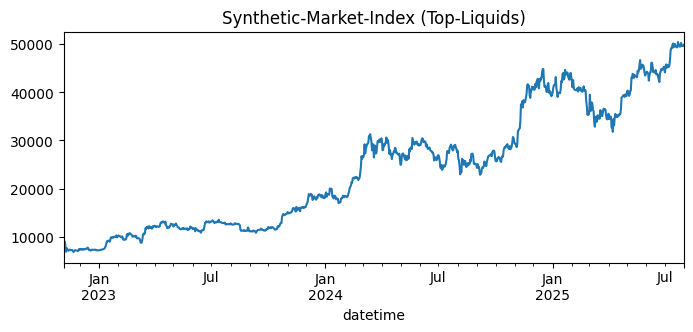

In [ ]:
market = MarketProxy(df_cryp_uni, top_n=3)

## index-weightage is independent of token-metadata (so NOT Ideal)
market_df, beta_basket = market.get_syn_index(ret_beta_basket=True)

print('Beta-Basket: ', beta_basket)

fig = plt.figure(figsize=(8, 3))
market_df.plot()
plt.title('Synthetic-Market-Index (Top-Liquids)')
plt.show()

In [54]:
## Call factor_model and pass the retrieved clean/data
factor_model = FactorModelPairs(stocks, variance_perc, is_plot=False)
pairs = factor_model.run(val_arr, df_uni, start_time=test_time, start_time_index=test_time_index)

Decomposed-Dim:  1
Agglom - nunmber of clusters generated:  9
 ---- Clusters ---- 

{1: ['1INCH/USDT', 'CELR/USDT', 'SAND/USDT', 'ROSE/USDT', 'STORJ/USDT', 'ZRX/USDT'], 8: ['BTC/USDT', 'BTC/USDT'], 0: ['API3/USDT', 'LDO/USDT'], 5: ['ETH/USDT'], 3: ['CRV/USDT', 'FLOW/USDT', 'STX/USDT', 'SUSHI/USDT'], 6: ['UNI/USDT'], 4: ['DASH/USDT'], 7: ['KSM/USDT'], 2: ['INJ/USDT']}

 ------------- 
Testing cointegration in cluster 1 with 6 symbols.
P-Value:  0.11823625552832967
P-Value:  0.19060701048630846
P-Value:  0.20904853615339014
P-Value:  0.2892764555902733
P-Value:  0.2040008792762094
P-Value:  0.4278137476502624
P-Value:  0.4887498891270253
P-Value:  0.4848025917711336
P-Value:  0.293573730963266
P-Value:  0.6249558559050963
P-Value:  0.10813390374852311
P-Value:  0.0906394897478725
P-Value:  0.15931054806072958
P-Value:  0.027969676697616328
Cointegrated pair found: ROSE/USDT_ZRX/USDT with p-value 0.027969676697616328 and Hurst -0.00
P-Value:  0.1266492532660783
Testing cointegration in cl

c:\Users\Alik\Desktop\M_year\MPhil\Options\Quant&Finance\QRT_Acad\ML-Pairs-Open\Research\utils\methods.py:42: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  coint_t, pvalue, _ = coint(prices_i, prices_j)


Cointegrated pair found: FLOW/USDT_SUSHI/USDT with p-value 0.00011910182036462214 and Hurst -0.03
P-Value:  0.5744861901938493
Number of Pairs Found:  4
Factors Successfully Modeled.


Predictive-Arbitrage (Alpha/Beta-Ex -> Risk-Engine)

In [55]:
initial_positions = {} ## No-Position
lookback_window = 60
entry_z = 2.5 
exit_z = 0.5

alpha_alloction = 0.4
beta_allocation = 0.6

In [58]:
## Call alpha_ex and pass the coint_pairs
alpha = PairsTradingAlpha(pairs, lookback_window=lookback_window, entry_z=entry_z, exit_z=exit_z)
target_position_alpha = alpha.generate_signal(timestamp=test_time, current_positions=initial_positions)

print('alpha-target-position: ', target_position_alpha)

alpha-target-position:  {'ROSE/USDT_ZRX/USDT': 0, 'BTC/USDT_BTC/USDT': 0, 'FLOW/USDT_STX/USDT': 0, 'FLOW/USDT_SUSHI/USDT': 0}


In [59]:
## Call beta_ex and get the beta_exposure
beta = SimpleMarketBeta(market_proxy=market_df, long_term_ma=200)
target_position_beta = beta.generate_signal(timestamp=test_time)

print('beta-target-position: ', target_position_beta)

beta-target-position:  0.0


In [60]:
## Call portfolio and pass the alpha and beta exposure
portfolio = PortfolioConstructor(alpha_allocation=alpha_alloction, beta_allocation=beta_allocation, beta_basket=beta_basket)
portfolio_weights = portfolio.construct_target_weights(alpha_signals=target_position_alpha, beta_signal=target_position_beta)
print('portfolio_weights: ', portfolio_weights)

portfolio_weights:  {}


In [ ]:
## Call risk_engine and add execution/liquidity/volume/positional caps/constraints
risk_manager = RiskManager(max_leverage=1, max_concentration=1, max_portfolio_drawdown=10)
hedged_portfoilo_weights = risk_manager.manage_weights(target_weights, portfolio_state)

Portfoilio-Backtesting

In [ ]:
## Call backtest and pass the risk-hedged position to test on out-of-sample historical data 
backtester = PerpetualFuturesBacktester(initial_capital, fee, pairs)
equity_series = backtester.run(data, funding_data, orchestrator: callable)

In [ ]:
display(equity_series)

In [ ]:
## Call forward test and pass the risk-hedged position for forward/live testing


In [ ]:
## Call/Save analytics on both the tests 